# 1. dio

Prvo trebamo uključiti sve biblioteke koje koristimo. Koristimo `pydataset` za unos podataka, `pandas` i `sklearn` za analizu te `seaborn` i `matplotlib` za grafičku reprezentaciju.

In [1]:
from pydataset import data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

U varijablu `frame` spremamo `pydataset` podatke o zrakoplovnim firmama u periodu od 15 godina (1970. - 1984.). Funkcija `data()` vraća tip `DataFrame` pa nema potrebe pretvarati.

In [2]:
frame = data("Airline")

Kako tablica uključuje podatke o više firmi, izabiremo samo jednu jer bi bilo besmisleno uspoređivati podatke između različitih firmi. Uspoređivat ćemo podatke iz stupaca `cost` (troškovi firme u godini) i `pf` (troškovi na gorivo u godini). Podatci o troškovima su u tisućama dolara (/1000$). Ostale stupce izbacujemo.

In [3]:
frame = frame[frame["airline"] == 1]
frame = frame[["cost", "pf"]]

In [4]:
costMean = frame["cost"].mean()
pfMean = frame["pf"].mean()

In [5]:
costMean

2639003.3333333335

In [6]:
pfMean

462320.2

In [7]:
pfMean/costMean

0.1751874255558601

Vidimo da je prosječna potrošnja na gorivo značajan udio prosječne potrošnje općenito.

Sada računamo standardne deviacije tih vrijednosti u tom rasponu. Kako su nam dostupne pune informacije u traženom rasponu, radimo s potpunim populacijama pa je potrebno pozvati funkciju s `ddof = 0`.

In [8]:
costStd = frame["cost"].std(ddof = 0)
pfStd = frame["pf"].std(ddof = 0)

In [9]:
costStd

1199381.7672376975

In [10]:
pfStd

331241.1615169427

Vidimo da je standardna devijacija stupca ``pf`` (tj. onome koji prikazuje trošak na gorivo) poprilično velika što sugerira da je potrošnja na gorivo varirala kroz velik raspon u tom periodu. Uistinu, oko 1980. godine cijena goriva je znatno skočila, a time i potrošnja na njega. Također je poprilično velika i vrijednost varijable ``costStd``; dakle, ukupni trošak je također podosta varirao što sugerira vezu između te dvije varijable.

Medijane računamo slično kao i aritmetičke sredine.

In [11]:
costMedian = frame["cost"].median()
pfMedian = frame["pf"].median()

In [12]:
costMedian

2314760.0

In [13]:
pfMedian

316411.0

Iz ovoga se eventualno može komentirati relativno velika razlika između vrijednosti varijabla ``pfMean`` i ``pfMedian`` što je očekivano budući da je i standardna devijacija velika.

In [14]:
(pfMean - pfMedian)/pfMean

0.3156020437783164

Kvartile možemo dobiti koristeći `quantile()` atribut. Potrebno je specificirati da se radi o kvartilima, tj. unijeti vrijednosti `[0.25, 0.5, 0.75]` kao argument. Također ga pretvorimo u `DataFrame` radi lakšeg ispisa i eventualnog budućeg rada.

In [15]:
costQuartiles = pd.DataFrame(frame["cost"].quantile([0.25, 0.5, 0.75]))
pfQuartiles = pd.DataFrame(frame["pf"].quantile([0.25, 0.5, 0.75]))

In [16]:
costQuartiles

,cost
0.25,1594130.0
0.50,2314760.0
0.75,3827750.0


In [17]:
pfQuartiles

,pf
0.25,159290.0
0.50,316411.0
0.75,841491.5


Iz kvartila se također može primijetiti velika razlika između najmanjih i najvećih vrijednosti stupaca ``pf`` i ``cost``, tj. da vrijednosti variraju u širokom rasponu.

Sada računamo kovarijancu i korelaciju. Iz sličnih razloga kao i prije, za kovarijancu je potrebno uključiti argument `ddof = 0`. Također, kako su nam vraćene vrijednosti tablice (u kojima je prikazana i kovarijanca/korelacija i varijabla `cost, pf` sa samim sobom, a to nam ne treba), potrebno je izabrati vrijednost iz ćelije koju želimo koristeći `iat`.

In [18]:
dataCov = frame.cov(ddof = 0).iat[0, 1]
dataCorr = frame.corr().iat[0, 1]

In [19]:
dataCov

381596215293.3334

In [20]:
dataCorr

0.9605109435241395

Vidimo da je korelacija jako blizu $1$ pa očekujemo da su varijable linearno povezane i smisleno je raditi linearnu regresiju. Također su obje vrijednosti pozitivne pa znamo da će veće vrijednosti varijable `pf` odgovarati većim vrijednostima varijable `cost` i obratno.

Sada generiramo pravac regresije i točkasti dijagram koristeći `seaborn` i `matplotlib` biblioteke. Kao zavisnu varijablu postavljamo ukupni trošak tako da vizualiziramo kako trošak na (a time i cijena) goriva utječu na ukupni trošak pojedine zrakoplovne firme. Također označujemo osi i cjelokupni dijagram. Obojat ćemo pravac u crveno radi preglednosti.

Text(0.5, 1.0, 'Odnos ukupnog troška i troška na gorivo')

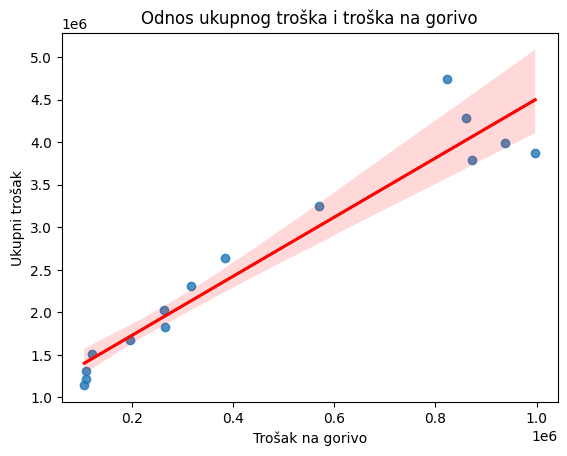

In [21]:
sns.regplot(x='pf', y='cost', data=frame, line_kws={"color":"red"})
plt.xlabel("Trošak na gorivo")
plt.ylabel("Ukupni trošak")
plt.title("Odnos ukupnog troška i troška na gorivo")

Vidimo vrlo visoku pozitivnu korelaciju između ukupnog troška i troška na gorivo. Vidimo da je pri većim vrijednostima parametra `pf` aproksimaija podataka pravcem nešto gora nego što je pri manjim, vjerojatno jer one odgovaraju periodu nestabilnosti cijena goriva oko 1980. godine što je možda narušilo vezu između varijabli. Svejedno, vidimo da su vrijednosti usko povezane pa je i ukupan trošak znatno skočio s troškom na gorivo.

Ako želimo prikazati samo pravac regresije ili samo točkasti dijagram možemo dodati redom ``scatter = False`` ili ``fit_reg = False`` kao argumente.

Text(0.5, 1.0, 'Odnos ukupnog troška i troška na gorivo')

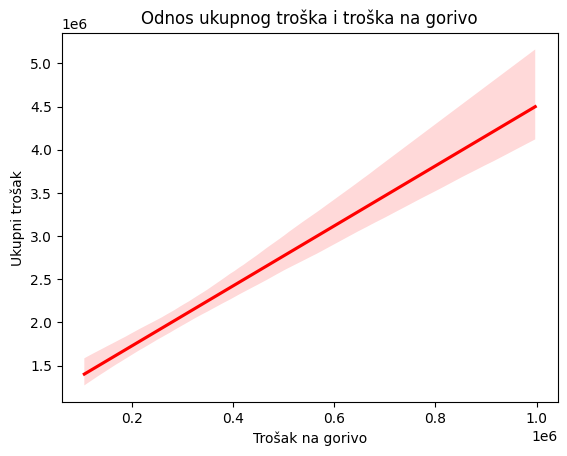

In [22]:
sns.regplot(x='pf', y='cost', data=frame, line_kws={"color":"red"}, scatter = False)
plt.xlabel("Trošak na gorivo")
plt.ylabel("Ukupni trošak")
plt.title("Odnos ukupnog troška i troška na gorivo")

Text(0.5, 1.0, 'Odnos ukupnog troška i troška na gorivo')

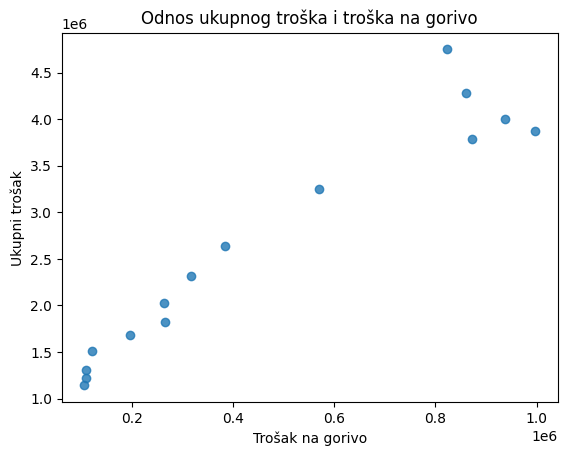

In [23]:
sns.regplot(x='pf', y='cost', data=frame, line_kws={"color":"red"}, fit_reg = False)
plt.xlabel("Trošak na gorivo")
plt.ylabel("Ukupni trošak")
plt.title("Odnos ukupnog troška i troška na gorivo")

# 2. dio

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import sklearn.datasets
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from pydataset import data
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.cluster import KMeans

Analizirat ćemo skup podataka ukupnog broja međunarodnih zrakoplovnih putnika po mjesecu, iskazanog u $\log_{10}(\frac{x}{1000})$ po godini, gdje je $x$ ukupan broj putnika tog mjeseca. Podatke unosimo pomoću `pydataset` biblioteke.

In [2]:
frame = data("AirPassengers")
frame

,time,AirPassengers
1,1949.000000,112
2,1949.083333,118
3,1949.166667,132
4,1949.250000,129
5,1949.333333,121
6,1949.416667,135
7,1949.500000,148
8,1949.583333,148
9,1949.666667,136
10,1949.750000,119


Obje varijable su neprekinute pa ćemo proučiti graf i napraviti regresiju. Zato podijelimo podatke u skupine za treniranje i testiranje.

In [3]:
x_train, x_test, y_train, y_test = train_test_split(frame[["time"]], frame["AirPassengers"], test_size=0.2, random_state=42)

Text(0, 0.5, 'Broj putnika')

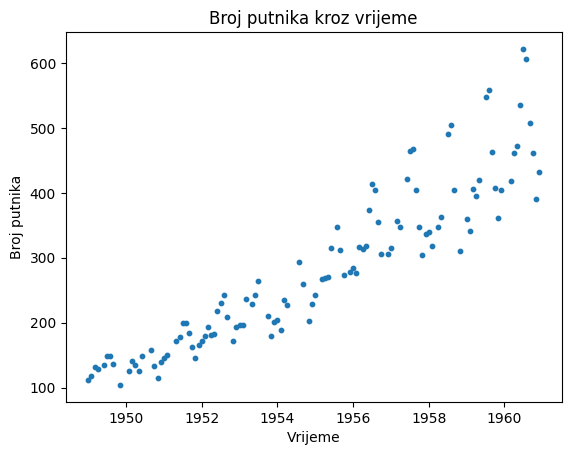

In [4]:
plt.scatter(x_train, y_train, s=10)
plt.title("Broj putnika kroz vrijeme")
plt.xlabel("Vrijeme")
plt.ylabel("Broj putnika")

Vidimo da je linearna funkcija dobar kandidat za regresiju. U tu svrhu koristimo `LinearRegression` iz `sklearn` biblioteke.

In [5]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

Vizualizirajmo podatke i linearnu regresiju.

Text(0, 0.5, 'Broj putnika')

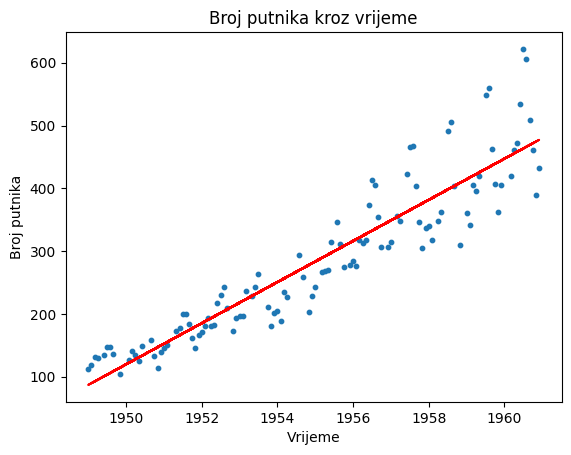

In [6]:
plt.scatter(x_train, y_train, s=10)
y_pred1 = lr.predict(x_train)
plt.plot(x_train, y_pred1, color='r')
plt.title("Broj putnika kroz vrijeme")
plt.xlabel("Vrijeme")
plt.ylabel("Broj putnika")

Iako je linearna funkcija poprilično dobra aproksimacija za podatke, vidimo iz grafa da bi polinomijalna (specifično kvadratna) funkcija mogla biti nešto bolja za podatke. Napravimo i polinomijalni model. 

In [7]:
pipeline = Pipeline([("poly", PolynomialFeatures(degree=2)), ("model", LinearRegression())])
pipeline.fit(x_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures()), ('model', LinearRegression())])

Vizualizirajmo i ovu regresiju. Kako `plt.plot()` traži da podatci za $x$ i $y$ budu u uzlaznom poretku, potrebno je prvo sortirati podatke.

Text(0, 0.5, 'Broj putnika')

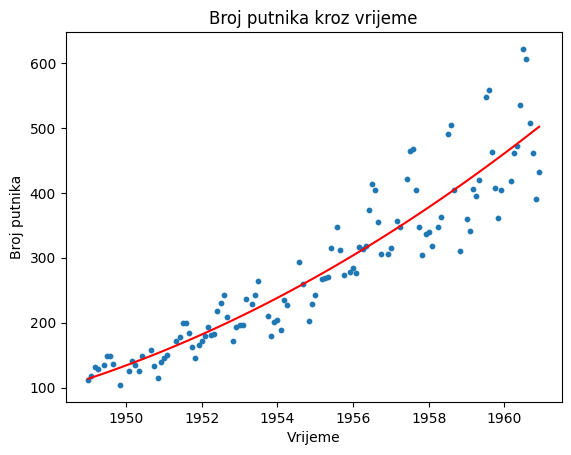

In [8]:
plt.scatter(x_train, y_train, s=10)
y_pred2 = pipeline.predict(x_train)
x_train_sorted = list(x_train["time"])
x_train_sorted.sort()
y_pred_sorted = list(y_pred2)
y_pred_sorted.sort()
plt.plot(x_train_sorted, y_pred_sorted, color='r')
plt.title("Broj putnika kroz vrijeme")
plt.xlabel("Vrijeme")
plt.ylabel("Broj putnika")

Vidimo da kvadratna funkcija nešto bolje odgovara podatcima. Sada validiramo oba modela tako što računamo `RMSE` i `R2` za varijable za treniranje i testiranje, a na kraju unakrsno validiramo. Varijable za linearni model indeksiramo sa `1`, a za polinomnijalni sa `2`.

In [9]:
RMSE1 = mean_squared_error(y_train, y_pred1, squared=False)
r21 = r2_score(y_train, y_pred1)
print(RMSE1)
print(r21)

47.31678336229581
0.8537140308232507


In [10]:
y_pred_test1 = lr.predict(x_test)
RMSEt1 = mean_squared_error(y_test, y_pred_test1, squared=False)
r2t1 = r2_score(y_test, y_pred_test1)
print(RMSEt1)
print(r2t1)

39.594633343814486
0.8422371912858828


In [11]:
scores = cross_val_score(lr, x_train, y_train, cv=3, scoring="neg_root_mean_squared_error")
RMSEc1 = -scores.mean()
print(RMSEc1)

47.60960765147397


In [12]:
scores_2 = cross_val_score(lr, x_train, y_train, cv=3, scoring="r2")
r2c1 = scores_2.mean()
print(r2c1)

0.8467381508358716


In [13]:
RMSE2 = mean_squared_error(y_train, y_pred2, squared=False)
r22 = r2_score(y_train, y_pred2)
print(RMSE2)
print(r22)

45.76774493307632
0.8631353548621308


In [14]:
y_pred_test2 = pipeline.predict(x_test)
RMSEt2 = mean_squared_error(y_test, y_pred_test2, squared=False)
r2t2 = r2_score(y_test, y_pred_test2)
print(RMSEt2)
print(r2t2)

39.30951888059312
0.8445010592035361


In [15]:
scores = cross_val_score(pipeline, x_train, y_train, cv=3, scoring="neg_root_mean_squared_error")
RMSEc2 = -scores.mean()
print(RMSEc2)

46.14233378519926


In [16]:
scores_2 = cross_val_score(pipeline, x_train, y_train, cv=3, scoring="r2")
r2c2 = scores_2.mean()
print(r2c2)

0.8556036425240805


Za kraj, stavimo sve podatke u `DataFrame` kako bismo lakše usporedili oba modela.

In [17]:
cmpData = [{"lin": RMSE1, "poly": RMSE2},
            {"lin": r21, "poly": r22},
            {"lin": RMSEt1, "poly": RMSEt2},
            {"lin": r2t1, "poly": r2t2},
            {"lin": RMSEc1, "poly": RMSEc2},
            {"lin": r2c1, "poly": r2c2}]
cmp = pd.DataFrame(cmpData, index=["RMSE", "R2", "RMSE Test", "R2 Test", "RMSE cross-validation", "R2 cross-validation"])
cmp

,lin,poly
RMSE,47.316783,45.767745
R2,0.853714,0.863135
RMSE Test,39.594633,39.309519
R2 Test,0.842237,0.844501
RMSE cross-validation,47.609608,46.142334
R2 cross-validation,0.846738,0.855604


Vidimo da je `R2` poprilično blizu $1$ u oba slučaja pa zaključujemo da su oba modela razumna. Također ni `RMSE` nije previsok. Međutim, ne vidimo veliko poboljšanje kod polinomijalnog modela u odnosu na linearni. Za kraj, usporedimo grafove modela.

Text(0, 0.5, 'Broj putnika')

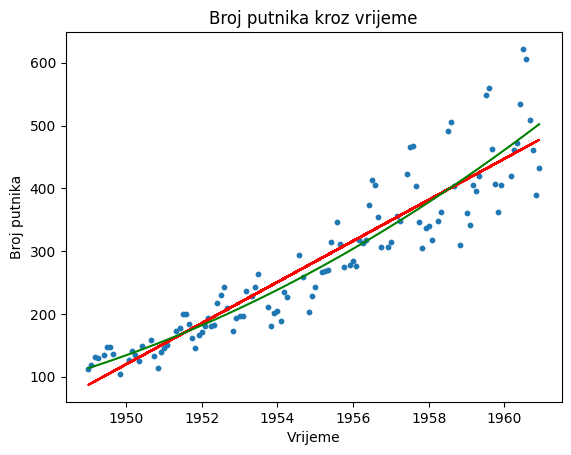

In [18]:
plt.scatter(x_train, y_train, s=10)
plt.plot(x_train, y_pred1, color='r')
plt.plot(x_train_sorted, y_pred_sorted, color='g')
plt.title("Broj putnika kroz vrijeme")
plt.xlabel("Vrijeme")
plt.ylabel("Broj putnika")

Vidimo da ni grafovi nisu posebice različiti. Zajedno s malim razlikama pri validaciji i relativno malim brojem podataka (oko 150 točaka) čini se vjerojatnije da je linearni model u ovoj situaciji korisniji. Ipak, kvadratni naizgled bolje opisuje podatke u kasnijim godinama koji znatno variraju pa bi mogao biti korisniji da imamo podatke za sljedeće godine.

Sada ćemo učitati podatke za klasteriranje. Koristimo `iris dataset` iz `sklearn` biblioteke. Podatci su o 3 različita tipa perunike i sadrže širine i dužine njihovih latica i lapova. Sve podatke spremamo u `frame` tako da nadodamo jedan stupac za tipove perunike.

In [19]:
frame = sklearn.datasets.load_iris(return_X_y = True, as_frame = True)[0]
target = sklearn.datasets.load_iris(return_X_y = True, as_frame = True)[1]
frame.insert(4, "y", target)
frame

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),y
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


Prvo ćemo vizualizirati podatke tako da prikažemo širinu i dužinu latice te dužinu lapa na dijagramu. Također ćemo obojati točke ovisno o tipu perunike.

Text(0.5, 0, 'Dužina lapa')

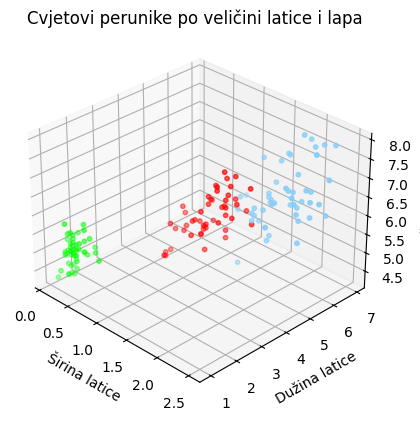

In [20]:
colors = np.array(["lime", "red", "lightskyblue"])

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.view_init(azim=-45)
ax.scatter(frame["petal width (cm)"], frame["petal length (cm)"], frame["sepal length (cm)"], s = 10, c = colors[np.array(frame["y"])])
plt.title("Cvjetovi perunike po veličini latice i lapa")
ax.set_xlabel("Širina latice")
ax.set_ylabel("Dužina latice")
ax.set_zlabel("Dužina lapa")

Rotirali smo dijagram tako da možemo razaznati tri grupacije: jedna, skroz na lijevoj strani, će vrlo očito predstavljati jedan klaster. Također vidimo da se druga dva tipa cvijeta otprilike (ali ne savršeno) raspoređuju u još dva klastera. Dakle, pokušat ćemo odrediti tip perunike iz ta tri podatka. Prvo određujemo broj klastera.

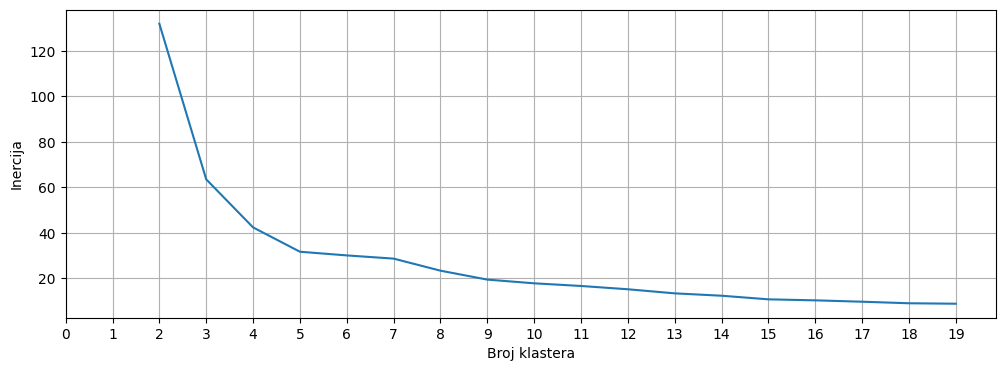

In [21]:
inercija = []

df = frame.filter(items=["petal width (cm)", "petal length (cm)", "sepal length (cm)"])

for k in range(2, 20):
    kmeans = KMeans(random_state=0, n_clusters=k)
    kmeans.fit(df)
    inercija.append(kmeans.inertia_)

plt.figure(figsize=(12, 4))
plt.grid()
plt.plot(range(2, 20), inercija)
plt.xticks(range(0, 20))
plt.xlabel("Broj klastera")
plt.ylabel("Inercija")
plt.show()

Najveći pad u inerciji je jasno od 2 do 3 klastera što je i očekivano iz prethodnih komentara. Iako postoji značajan pad s 3 na 4 i s 4 na 5, pad s 2 na 3 je više puta veći, a i na prijašnjem grafu izgleda kao da su 3 klastera optimalan broj. Zato ćemo uzeti 3. Izvršavamo *k-means* algoritam:

In [22]:
kmeans = KMeans(random_state=0, n_clusters=3)
kmeans.fit(df)
print(kmeans.cluster_centers_)

[[1.41       4.37166667 5.89666667]
 [0.246      1.462      5.006     ]
 [2.075      5.7075     6.81      ]]


Nadodat ćemo klastere u `DataFrame` s podatcima radi lakšeg korištenja.

In [23]:
frame["Cluster"] = kmeans.labels_
frame

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),y,Cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1
5,5.4,3.9,1.7,0.4,0,1
6,4.6,3.4,1.4,0.3,0,1
7,5.0,3.4,1.5,0.2,0,1
8,4.4,2.9,1.4,0.2,0,1
9,4.9,3.1,1.5,0.1,0,1


Primijetimo da je algoritam "obrnuo" oznake za prvi i drugi tip perunike. Naravno, nema razloga za očekivati da će one biti iste i to ne utječe na analizu, ali obrnut ćemo ih svejedno radi lakšeg uspoređivanja s prijašnjom vizualizacijom.

In [24]:
def f(x):
    if (x == 1):
        return 0
    elif (x == 0):
        return 1
    else:
        return x

frame["Cluster"] = frame["Cluster"].apply(f)
frame

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),y,Cluster
0,5.1,3.5,1.4,0.2,0,0
1,4.9,3.0,1.4,0.2,0,0
2,4.7,3.2,1.3,0.2,0,0
3,4.6,3.1,1.5,0.2,0,0
4,5.0,3.6,1.4,0.2,0,0
5,5.4,3.9,1.7,0.4,0,0
6,4.6,3.4,1.4,0.3,0,0
7,5.0,3.4,1.5,0.2,0,0
8,4.4,2.9,1.4,0.2,0,0
9,4.9,3.1,1.5,0.1,0,0


Sada možemo vizualizirati podatke slično kao i prije, samo što ovaj put dodajemo središta klastera i bojamo po klasterima, a ne po tipu cvijeta. 

Text(0.5, 0, 'Dužina lapa')

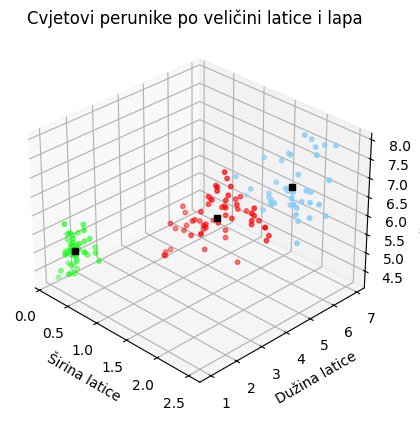

In [25]:
fig = plt.figure()
ax = fig.add_subplot(projection="3d", computed_zorder = False)
ax.view_init(azim=-45)
for x in kmeans.cluster_centers_:
    ax.scatter(x[0], x[1], x[2], marker="s", c="black", zorder = 1)
ax.scatter(frame["petal width (cm)"], frame["petal length (cm)"], frame["sepal length (cm)"], s = 10, c = colors[np.array(frame["Cluster"])], zorder = -1)
plt.title("Cvjetovi perunike po veličini latice i lapa")
ax.set_xlabel("Širina latice")
ax.set_ylabel("Dužina latice")
ax.set_zlabel("Dužina lapa")

Vidimo da smo dobili sličnu sliku kao i prije. Na primjer, zeleni klaster na lijevo se u potpunosti preklapa s odgovarajućim tipom cvijeta. Između crvenog i plavog klastera smo očekivali nepreciznosti, kojih uistinu ima, ali većinom se preklapaju s odgovarajućim tipovima. Za kraj, možemo provjeriti s kojom smo točnosti ovim algoritmom predvidjeli tip perunike:

In [26]:
corCluster = 0
totalCluster = len(frame["Cluster"]) + 1

for i in range(totalCluster - 1):
    if frame["Cluster"][i] == frame["y"][i]:
        corCluster += 1

print(corCluster/totalCluster)

0.9006622516556292


Vidimo da je točnost bila oko 90%, tj. oko 90% svih podataka je svrstano u klaster koji odgovara njihovom tipu. Konačno, zaključujemo da se iz podataka o dužini i širini latice te dužini lapa perunike može odrediti njen tip s visokom razinom sigurnosti.